In [1]:
# Cell 1 — Imports
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

REPORTS = "../artifacts/reports"
MODELS  = "../artifacts/model"

print("Imports OK")

Imports OK


In [2]:
# Cell 2 — Load all result files

with open(f"{REPORTS}/drift_scores.json") as f:
    drift = json.load(f)

with open(f"{REPORTS}/cross_eval_accuracy.json") as f:
    evals = json.load(f)

# Rolling drift (new)
rolling_path = f"{REPORTS}/rolling_drift_scores.json"
rolling = json.load(open(rolling_path)) if os.path.exists(rolling_path) else []

# Drift alerts (new)
alerts_path = f"{REPORTS}/drift_alerts.json"
alerts = json.load(open(alerts_path)) if os.path.exists(alerts_path) else []

# Short batch labels
SHORT = {
    "Monday-WorkingHours.pcap_ISCX.csv"                         : "Mon",
    "Tuesday-WorkingHours.pcap_ISCX.csv"                        : "Tue",
    "Wednesday-workingHours.pcap_ISCX.csv"                      : "Wed",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"    : "Thu AM",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv": "Thu PM",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv"                 : "Fri AM",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv"      : "Fri Port",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"          : "Fri DDoS",
}

df_drift   = pd.DataFrame(drift)
df_eval    = pd.DataFrame(evals)
df_drift["label"] = df_drift["comparison_batch"].map(SHORT)
df_eval["label"]  = df_eval["batch"].map(SHORT)

MODELS_LIST = df_eval["model"].unique().tolist() if "model" in df_eval.columns else ["random_forest"]
print(f"Models in cross-eval: {MODELS_LIST}")
print(f"Batches: {df_drift['label'].tolist()}")
print(f"Alerts: {len(alerts)}")

Models in cross-eval: ['random_forest', 'xgboost', 'logistic', 'decision_tree', 'svm']
Batches: ['Tue', 'Wed', 'Thu AM', 'Thu PM', 'Fri AM', 'Fri Port', 'Fri DDoS']
Alerts: 3


## Figure 1 — Multi-model cross-dataset accuracy
One subplot per model. Shows how each model family degrades under drift.

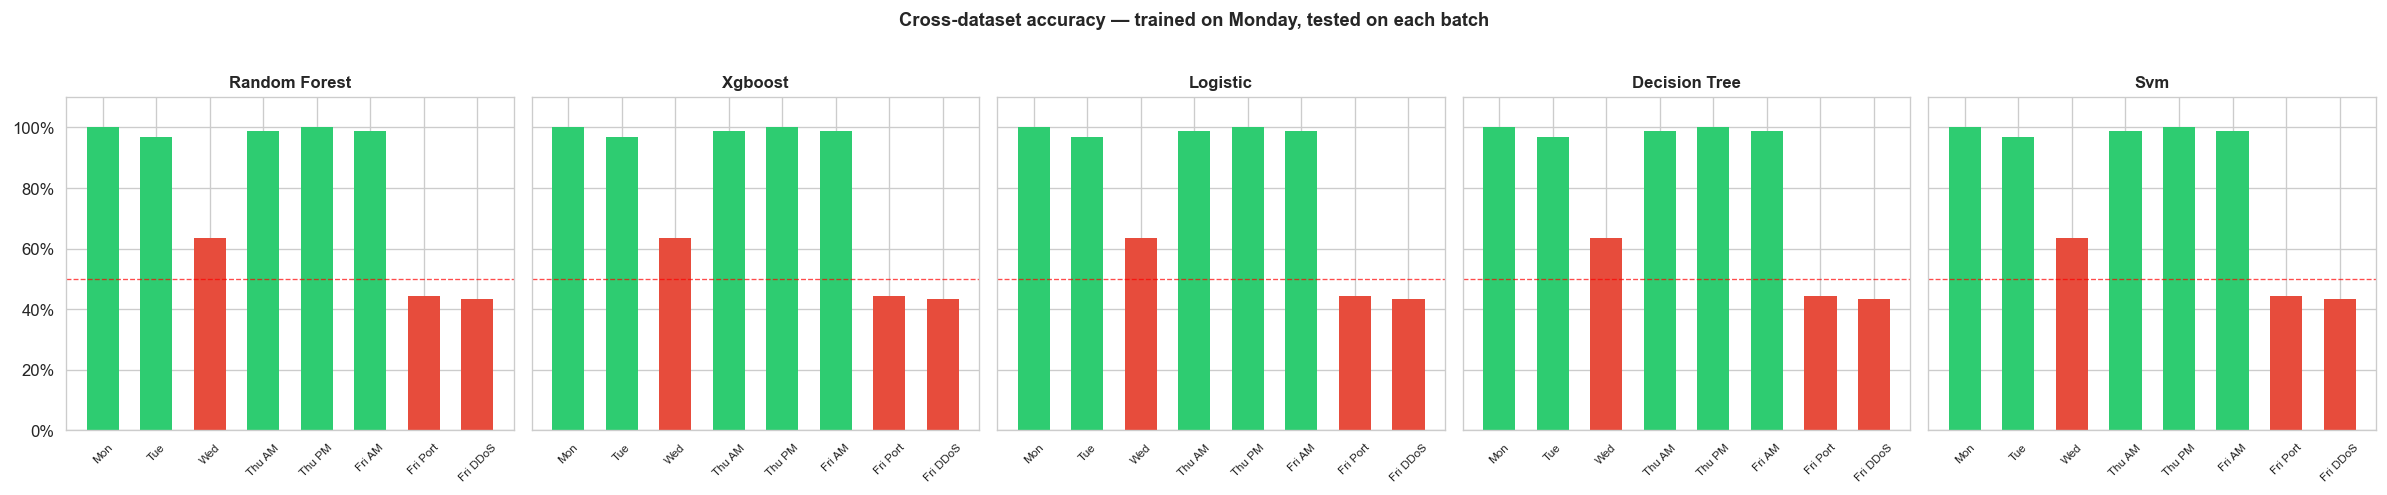

Saved fig1_multimodel_accuracy.png


In [4]:
# Cell 3 — Figure 1: Multi-model cross-dataset accuracy (one panel per model)

if "model" in df_eval.columns:
    models = MODELS_LIST
else:
    models = ["random_forest"]

n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, model_name in zip(axes, models):
    sub = df_eval[df_eval["model"] == model_name].copy() if "model" in df_eval.columns else df_eval.copy()
    colors = ["#2ecc71" if a > 0.95 else "#f39c12" if a > 0.7 else "#e74c3c"
              for a in sub["accuracy"]]
    ax.bar(sub["label"], sub["accuracy"] * 100, color=colors, edgecolor="none", width=0.6)
    ax.axhline(50, color="red", linewidth=0.8, linestyle="--", alpha=0.7)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(model_name.replace("_", " ").title(), fontsize=10, fontweight="bold")
    ax.set_ylim(0, 110)
    ax.tick_params(axis="x", rotation=45, labelsize=7)

fig.suptitle("Cross-dataset accuracy — trained on Monday, tested on each batch",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{REPORTS}/fig1_multimodel_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig1_multimodel_accuracy.png")

## Figure 2 — Model comparison heatmap
All models and all batches in one view. Reveals which models degrade fastest.

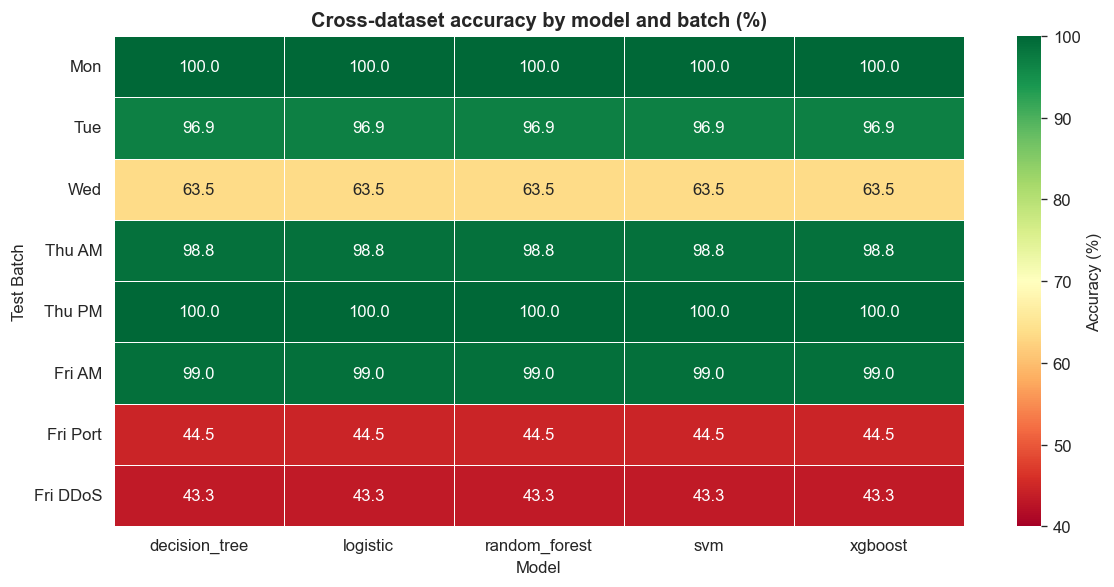

Saved fig2_model_comparison_heatmap.png


In [6]:
# Cell 4 — Figure 2: Model comparison heatmap (batches x models)

if "model" in df_eval.columns:
    pivot = df_eval.pivot_table(index="label", columns="model",
                                values="accuracy", aggfunc="first")
    # Preserve batch order
    batch_order = [SHORT[k] for k in [
        "Monday-WorkingHours.pcap_ISCX.csv",
        "Tuesday-WorkingHours.pcap_ISCX.csv",
        "Wednesday-workingHours.pcap_ISCX.csv",
        "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
        "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
        "Friday-WorkingHours-Morning.pcap_ISCX.csv",
        "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
        "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    ] if SHORT.get(k) in pivot.index]
    pivot = pivot.reindex(batch_order)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(pivot * 100, annot=True, fmt=".1f", cmap="RdYlGn",
                vmin=40, vmax=100, ax=ax, linewidths=0.5,
                cbar_kws={"label": "Accuracy (%)"})
    ax.set_title("Cross-dataset accuracy by model and batch (%)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Model")
    ax.set_ylabel("Test Batch")
    plt.tight_layout()
    plt.savefig(f"{REPORTS}/fig2_model_comparison_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved fig2_model_comparison_heatmap.png")
else:
    print("Single-model eval — skipping heatmap. Run testdrift.py with all 5 models.")

## Figure 3 — Divergence metrics comparison (KL, JS, Wasserstein)
Shows all three metrics side by side for each batch comparison.

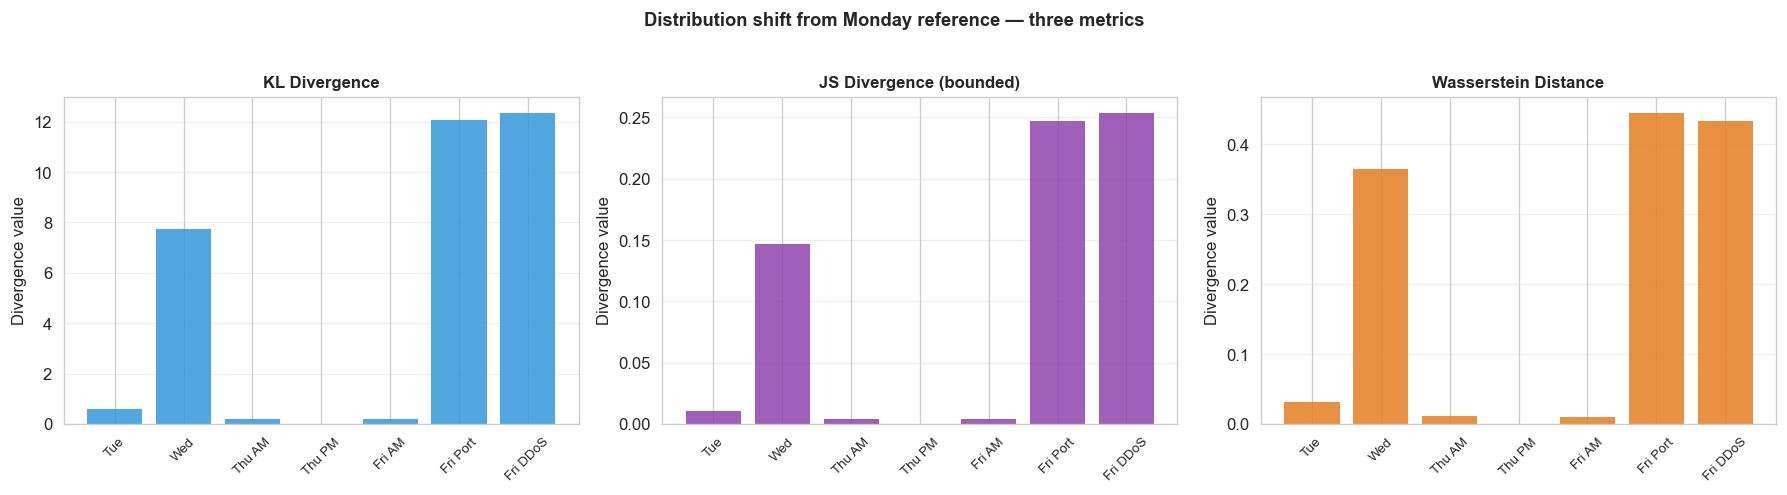

Saved fig3_divergence_metrics.png


In [8]:
# Cell 5 — Figure 3: KL, JS and Wasserstein divergence side by side

has_ws = "label_wasserstein" in df_drift.columns
n_metrics = 3 if has_ws else 2
fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 4))

metrics = [
    ("label_kl_divergence",  "KL Divergence",            "#3498db"),
    ("label_js_divergence",  "JS Divergence (bounded)",  "#8e44ad"),
]
if has_ws:
    metrics.append(("label_wasserstein", "Wasserstein Distance", "#e67e22"))

for ax, (col, title, colour) in zip(axes, metrics):
    ax.bar(df_drift["label"], df_drift[col], color=colour, edgecolor="none", alpha=0.85)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylabel("Divergence value")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Distribution shift from Monday reference — three metrics",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{REPORTS}/fig3_divergence_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig3_divergence_metrics.png")

## Figure 4 — Rolling window vs fixed reference drift
Fixed reference measures cumulative drift from Monday. Rolling window measures batch-to-batch step change.

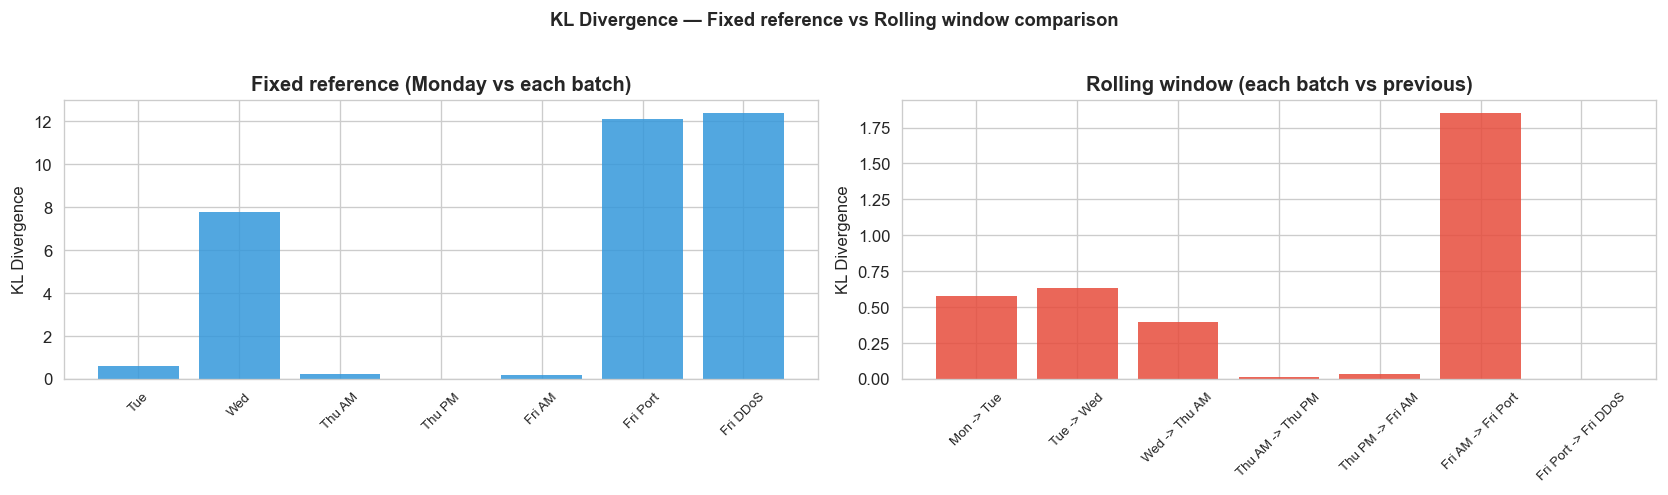

Saved fig4_rolling_vs_fixed.png


In [10]:
# Cell 6 — Figure 4: Rolling drift vs Fixed reference drift

if rolling:
    df_rolling = pd.DataFrame(rolling)
    df_rolling["ref_label"]  = df_rolling["reference_batch"].map(SHORT)
    df_rolling["curr_label"] = df_rolling["comparison_batch"].map(SHORT)
    df_rolling["pair"] = df_rolling["ref_label"] + " -> " + df_rolling["curr_label"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Fixed reference (cumulative from Monday)
    axes[0].bar(df_drift["label"], df_drift["label_kl_divergence"],
                color="#3498db", edgecolor="none", alpha=0.85)
    axes[0].set_title("Fixed reference (Monday vs each batch)", fontweight="bold")
    axes[0].set_ylabel("KL Divergence")
    axes[0].tick_params(axis="x", rotation=45, labelsize=8)

    # Rolling window (consecutive)
    axes[1].bar(df_rolling["pair"], df_rolling["label_kl_divergence"],
                color="#e74c3c", edgecolor="none", alpha=0.85)
    axes[1].set_title("Rolling window (each batch vs previous)", fontweight="bold")
    axes[1].set_ylabel("KL Divergence")
    axes[1].tick_params(axis="x", rotation=45, labelsize=8)

    fig.suptitle("KL Divergence — Fixed reference vs Rolling window comparison",
                 fontsize=11, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(f"{REPORTS}/fig4_rolling_vs_fixed.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved fig4_rolling_vs_fixed.png")
else:
    print("No rolling drift data found. Set USE_ROLLING_REFERENCE=True in config.py and re-run testdrift.py")

## Figure 5 — Core finding: KL divergence vs accuracy (per model)
One scatter per model. The negative relationship should be consistent across all model families.

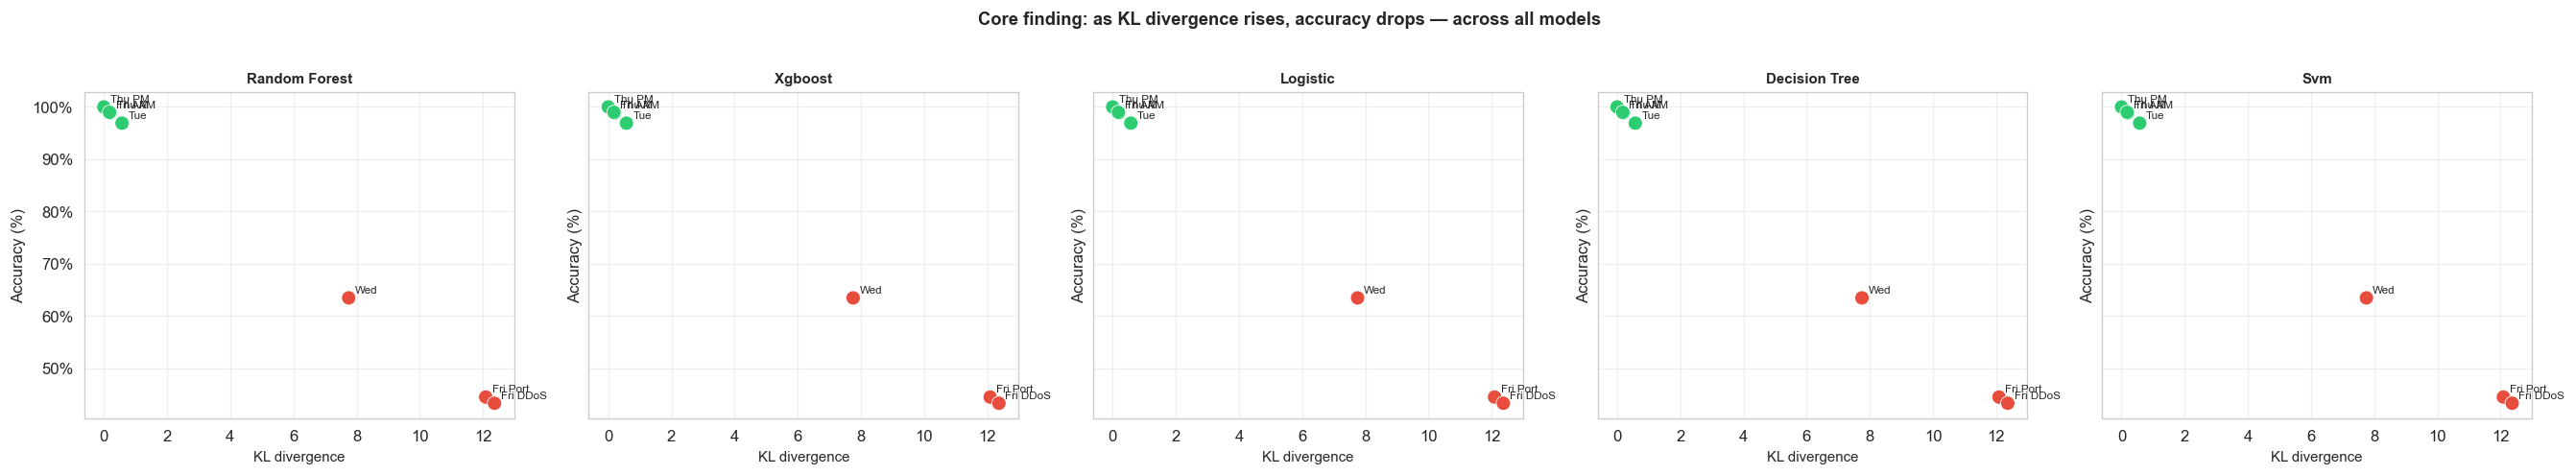

Saved fig5_kl_vs_accuracy_multimodel.png


In [12]:
# Cell 7 — Figure 5: KL divergence vs accuracy, one panel per model

if "model" in df_eval.columns:
    models = MODELS_LIST
    n = len(models)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4), sharey=True, sharex=True)
    if n == 1:
        axes = [axes]

    for ax, model_name in zip(axes, models):
        sub = df_eval[df_eval["model"] == model_name].copy()
        # Exclude Monday (self-eval) for the scatter
        sub = sub[sub["note"].str.contains("cross")]
        merged_m = df_drift[["label","label_kl_divergence"]].merge(sub[["label","accuracy"]], on="label", how="inner")

        colors_s = ["#2ecc71" if a > 0.95 else "#f39c12" if a > 0.7 else "#e74c3c"
                    for a in merged_m["accuracy"]]
        ax.scatter(merged_m["label_kl_divergence"], merged_m["accuracy"]*100,
                   s=80, c=colors_s, zorder=5, edgecolors="white", linewidth=0.5)
        for _, row in merged_m.iterrows():
            ax.annotate(row["label"],
                        (row["label_kl_divergence"], row["accuracy"]*100),
                        textcoords="offset points", xytext=(4, 3), fontsize=7)
        ax.set_title(model_name.replace("_", " ").title(), fontsize=9, fontweight="bold")
        ax.set_xlabel("KL divergence", fontsize=9)
        ax.set_ylabel("Accuracy (%)")
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.grid(alpha=0.3)

    fig.suptitle("Core finding: as KL divergence rises, accuracy drops — across all models",
                 fontsize=11, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(f"{REPORTS}/fig5_kl_vs_accuracy_multimodel.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved fig5_kl_vs_accuracy_multimodel.png")

## Figure 6 — Feature drift heatmap
Per-feature JS divergence. Shows which specific network features shift most in each attack scenario.

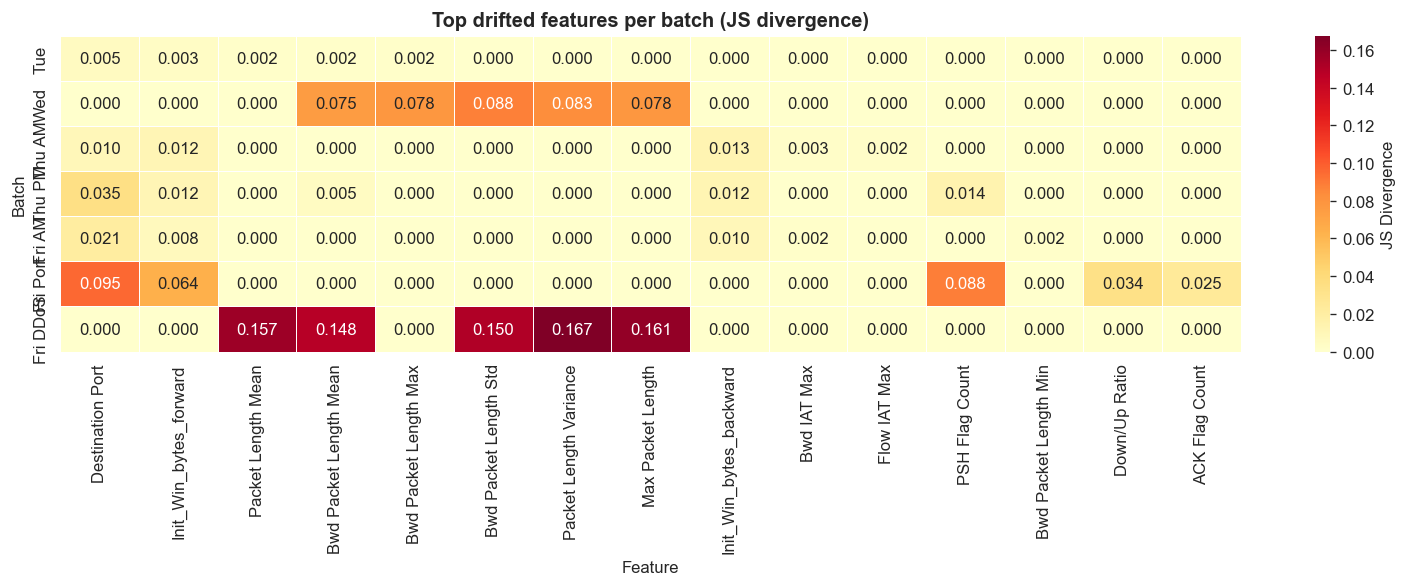

Saved fig6_feature_drift_heatmap.png


In [14]:
# Cell 8 — Figure 6: Feature drift heatmap (top drifted features per batch)

feat_data = {}
for rec in drift:
    key = SHORT.get(rec["comparison_batch"], rec["comparison_batch"][-10:])
    feat_data[key] = rec["top_drifted_features"]

feat_df = pd.DataFrame(feat_data).T.fillna(0)
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(feat_df, annot=True, fmt=".3f", cmap="YlOrRd",
            ax=ax, linewidths=0.5, cbar_kws={"label": "JS Divergence"})
ax.set_title("Top drifted features per batch (JS divergence)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Feature")
ax.set_ylabel("Batch")
plt.tight_layout()
plt.savefig(f"{REPORTS}/fig6_feature_drift_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig6_feature_drift_heatmap.png")

## Figure 7 — Drift predictor: actual vs predicted accuracy
Linear regression meta-model trained on divergence scores to predict cross-dataset accuracy.

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.8.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


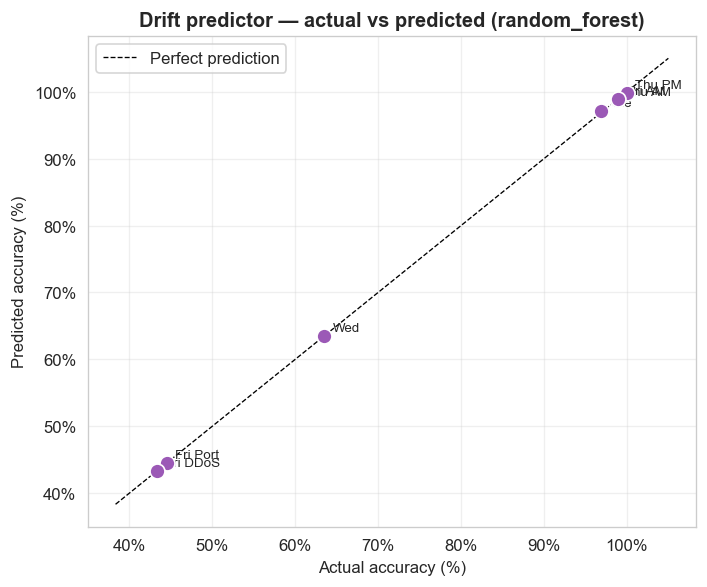

Saved fig7_predicted_vs_actual.png


In [35]:
# Cell 9 — Figure 7: Drift predictor actual vs predicted

predictor_path = f"{MODELS}/drift_predictor_linear_regression.pkl"
if not os.path.exists(predictor_path):
    print("Drift predictor not found. Run drift_predictor.py first.")
else:
    predictor = joblib.load(predictor_path)

    # Use Random Forest cross-eval as reference (or first model available)
    if "model" in df_eval.columns:
        ref_model = "random_forest" if "random_forest" in MODELS_LIST else MODELS_LIST[0]
        sub_rf = df_eval[
            (df_eval["model"] == ref_model) &
            (df_eval["note"].str.contains("cross"))
        ].copy()
    else:
        sub_rf = df_eval[df_eval["note"].str.contains("cross")].copy()

    merged_pred = df_drift[["label","label_kl_divergence",
                             "label_js_divergence","mean_feature_js"]].merge(
        sub_rf[["label","accuracy"]], on="label", how="inner")

    X_pred  = merged_pred[["label_kl_divergence","label_js_divergence","mean_feature_js"]].values
    y_pred  = predictor.predict(X_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(merged_pred["accuracy"]*100, y_pred*100,
               s=80, color="#9b59b6", zorder=5, edgecolors="white")
    lo = min(merged_pred["accuracy"].min()*100, y_pred.min()*100) - 5
    hi = 105
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.8, label="Perfect prediction")
    for i, row in merged_pred.iterrows():
        ax.annotate(row["label"],
                    (row["accuracy"]*100, y_pred[i]*100),
                    textcoords="offset points", xytext=(5, 3), fontsize=8)
    ax.set_xlabel("Actual accuracy (%)")
    ax.set_ylabel("Predicted accuracy (%)")
    ax.set_title(f"Drift predictor — actual vs predicted ({ref_model})",
                 fontweight="bold")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{REPORTS}/fig7_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved fig7_predicted_vs_actual.png")

## Figure 8 — SHAP analysis under drift
Loads saved SHAP comparison plots from shap_analysis.py. If not yet generated, instructions are printed.


--- SHAP: random_forest ---


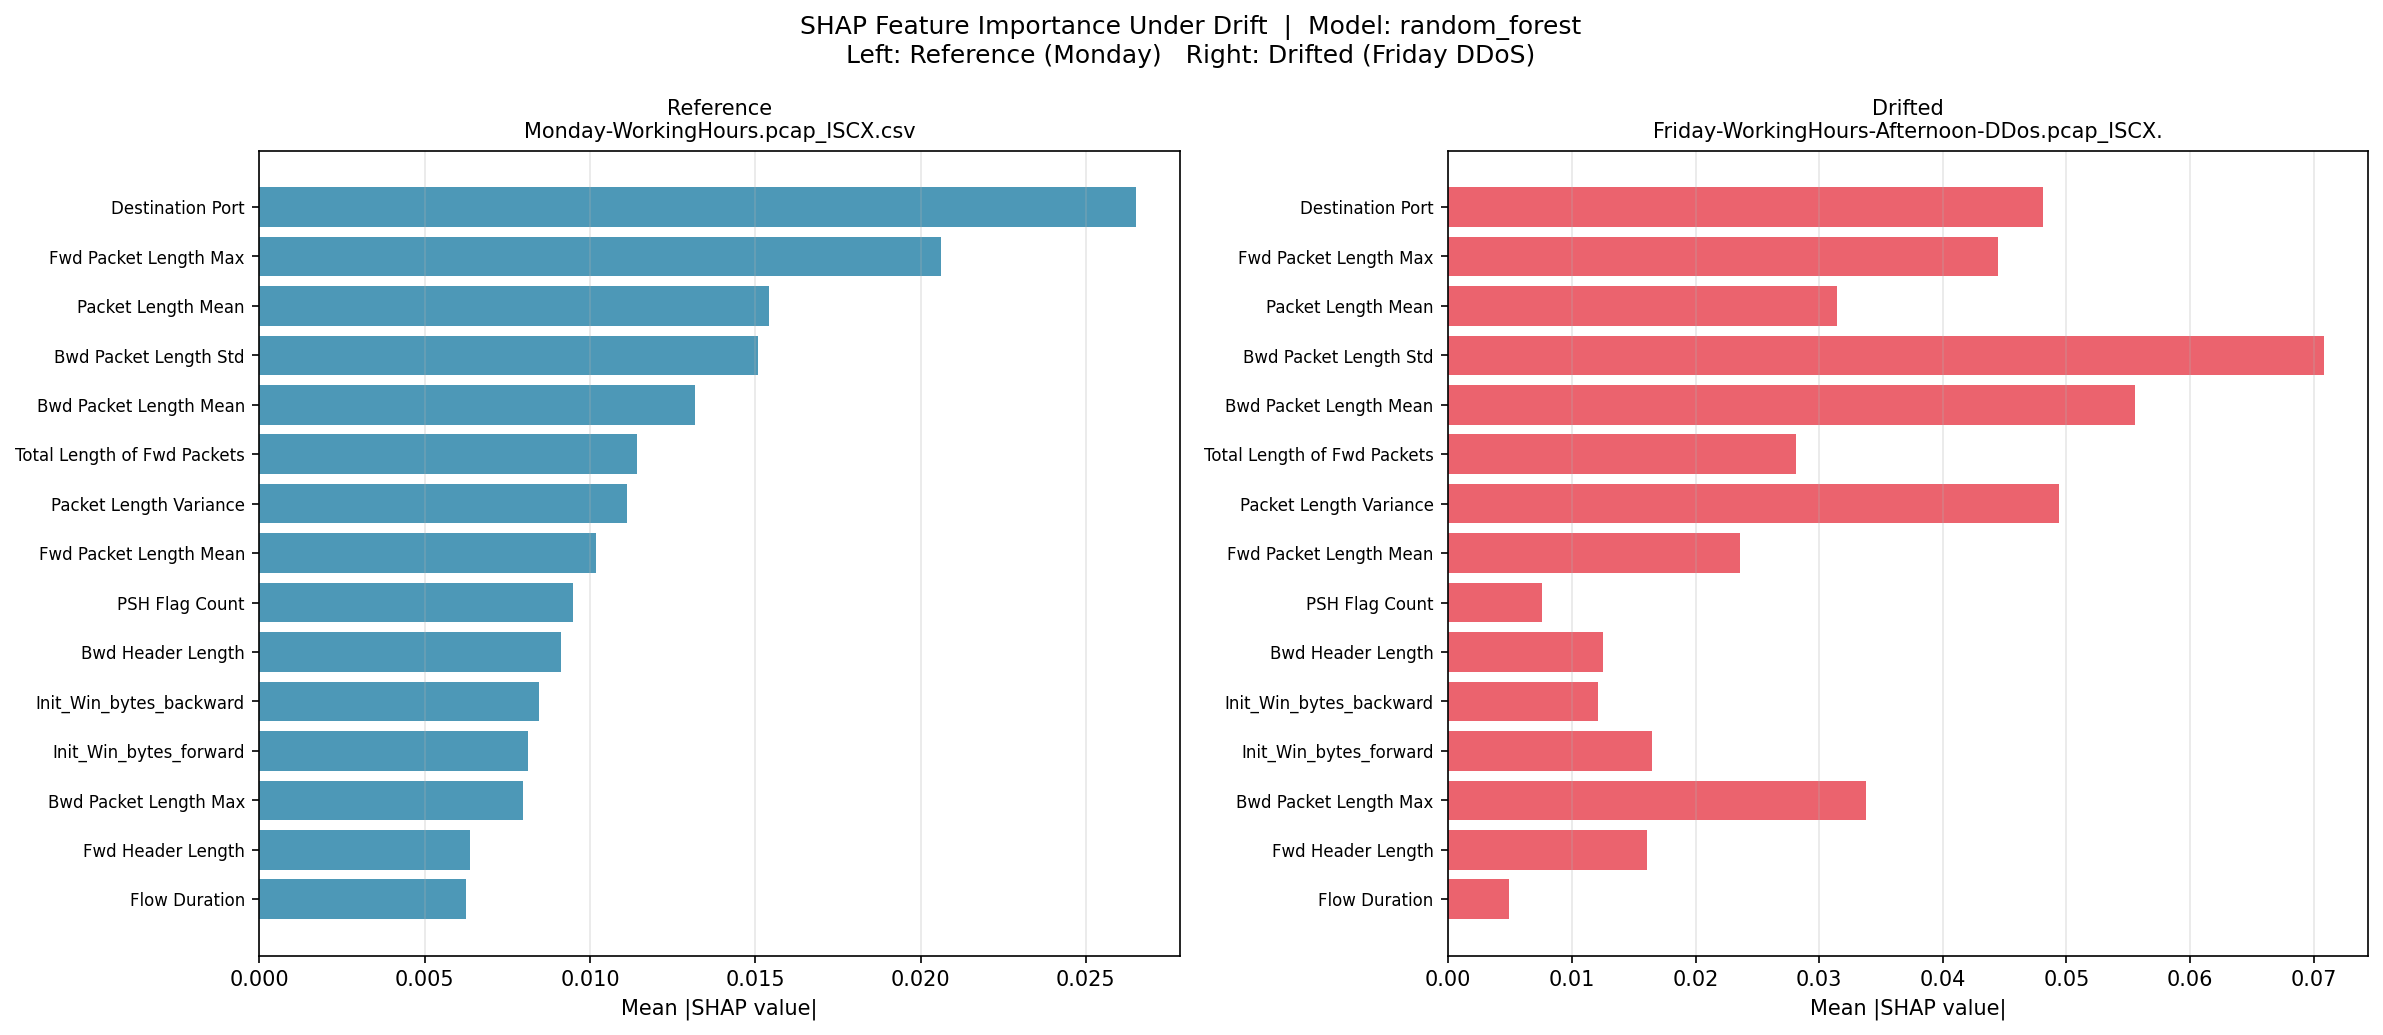

  Top 5 features (by reference importance):
    Destination Port                       ref=0.0265  drift=0.0481  delta=+0.0216
    Fwd Packet Length Max                  ref=0.0206  drift=0.0444  delta=+0.0238
    Packet Length Mean                     ref=0.0154  drift=0.0315  delta=+0.0161
    Bwd Packet Length Std                  ref=0.0151  drift=0.0709  delta=+0.0558
    Bwd Packet Length Mean                 ref=0.0132  drift=0.0556  delta=+0.0424

--- SHAP: xgboost ---


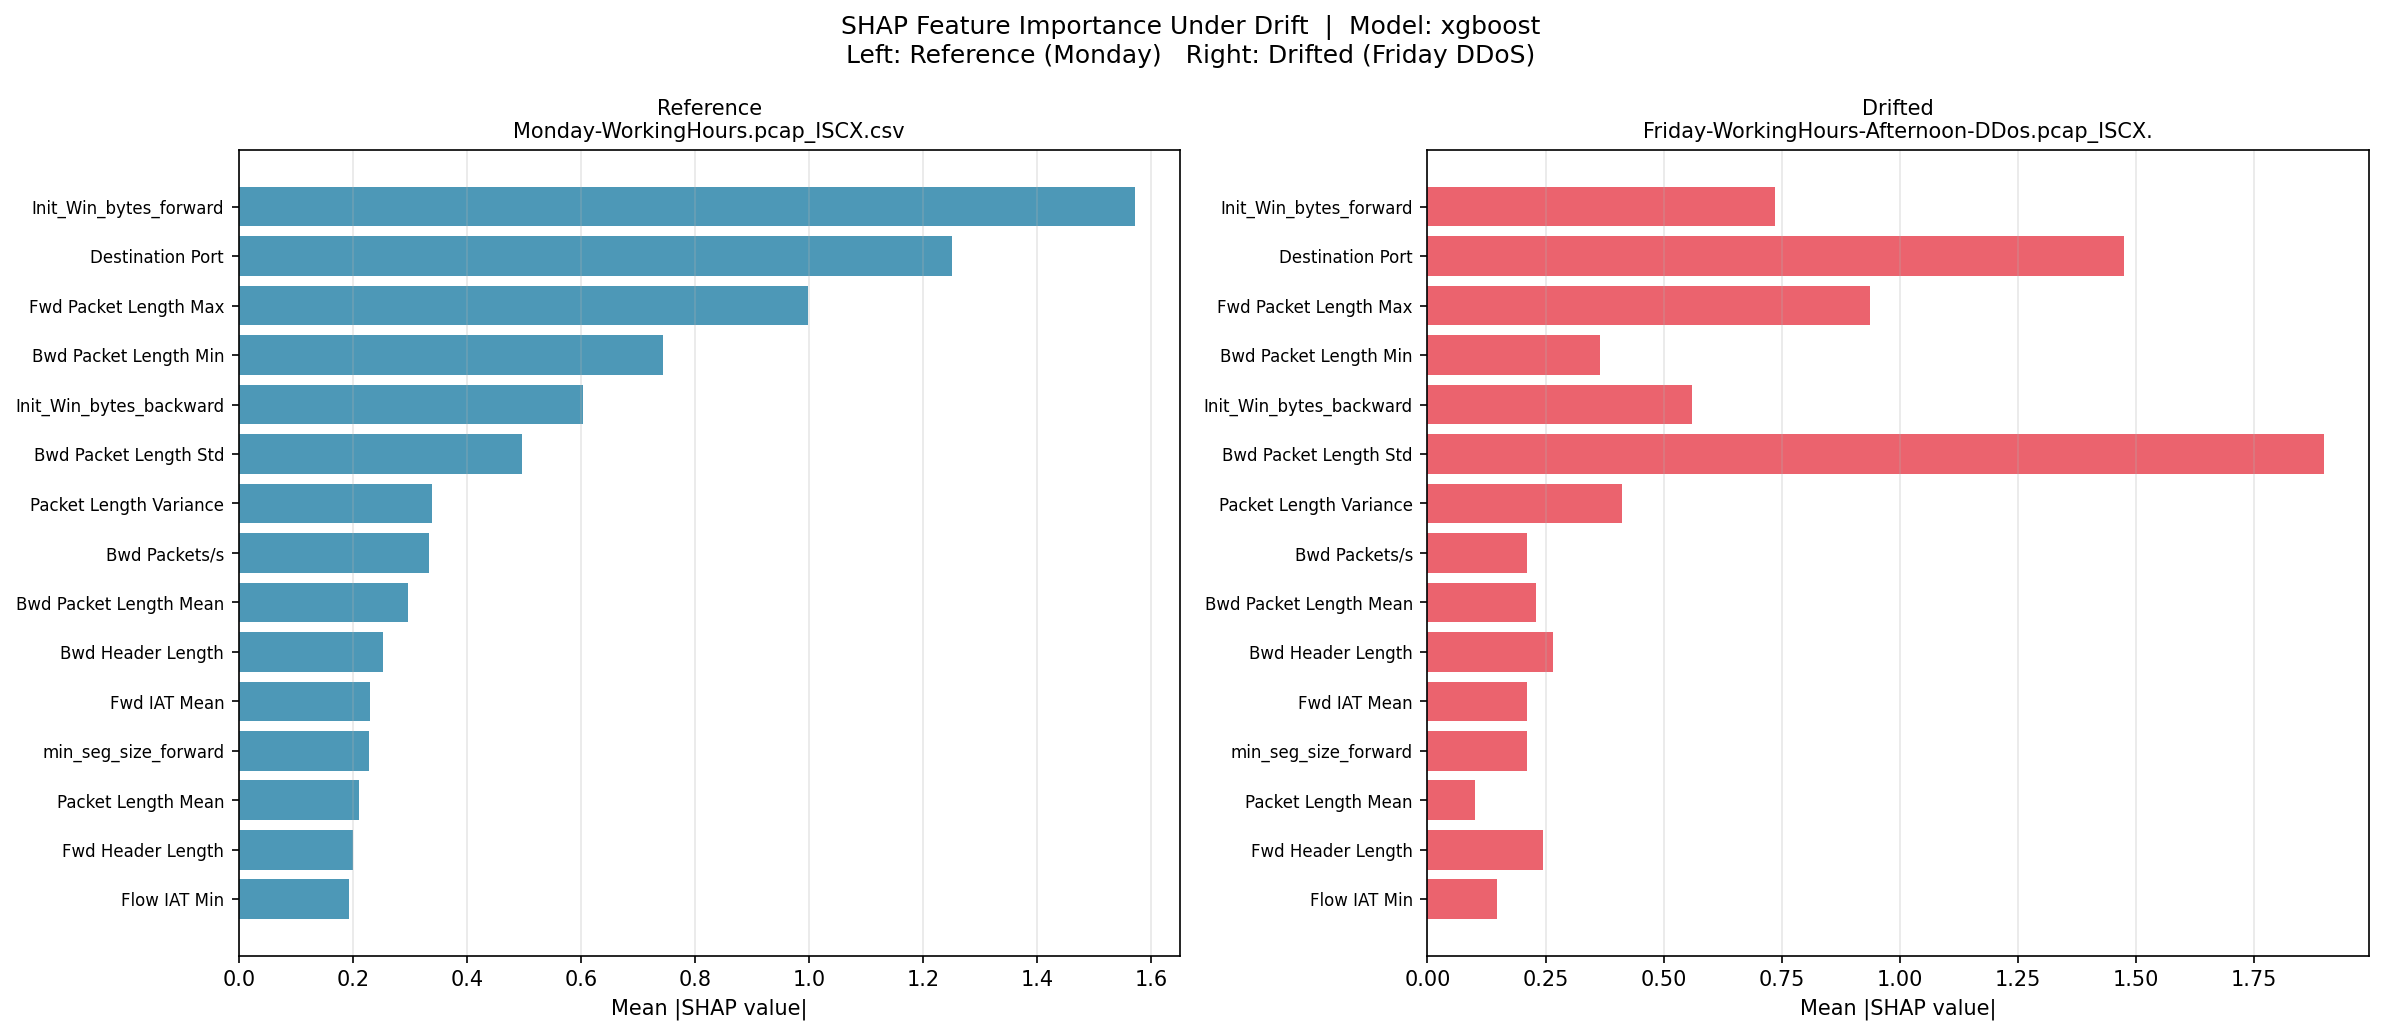

  Top 5 features (by reference importance):
    Init_Win_bytes_forward                 ref=1.5721  drift=0.7364  delta=-0.8358
    Destination Port                       ref=1.2514  drift=1.4743  delta=+0.2229
    Fwd Packet Length Max                  ref=0.9991  drift=0.9372  delta=-0.0619
    Bwd Packet Length Min                  ref=0.7446  drift=0.3660  delta=-0.3786
    Init_Win_bytes_backward                ref=0.6041  drift=0.5600  delta=-0.0442

--- SHAP: decision_tree ---


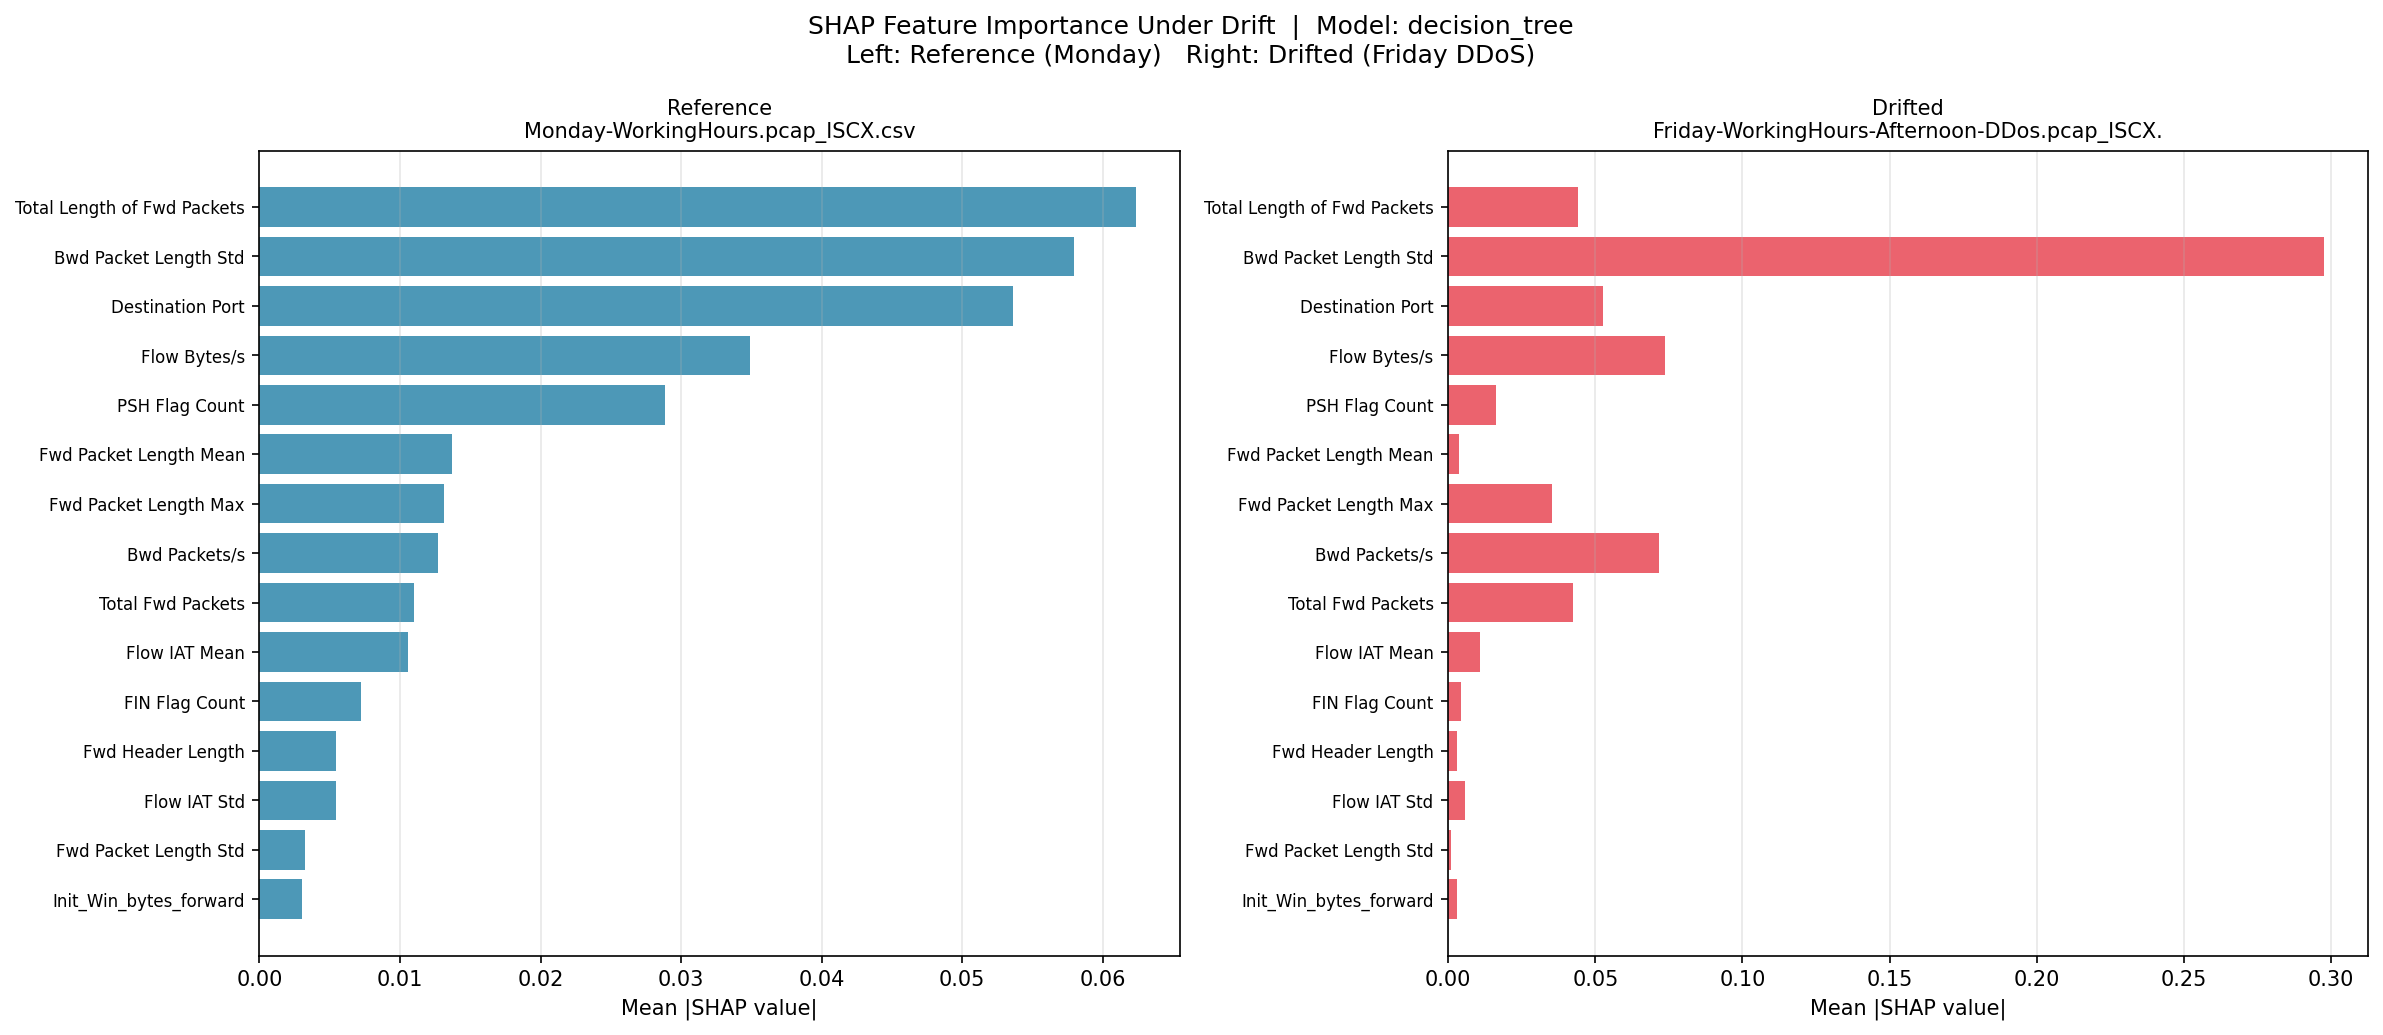

  Top 5 features (by reference importance):
    Total Length of Fwd Packets            ref=0.0624  drift=0.0443  delta=-0.0181
    Bwd Packet Length Std                  ref=0.0579  drift=0.2978  delta=+0.2399
    Destination Port                       ref=0.0536  drift=0.0526  delta=-0.0011
    Flow Bytes/s                           ref=0.0349  drift=0.0735  delta=+0.0386
    PSH Flag Count                         ref=0.0289  drift=0.0162  delta=-0.0127

--- SHAP: logistic ---


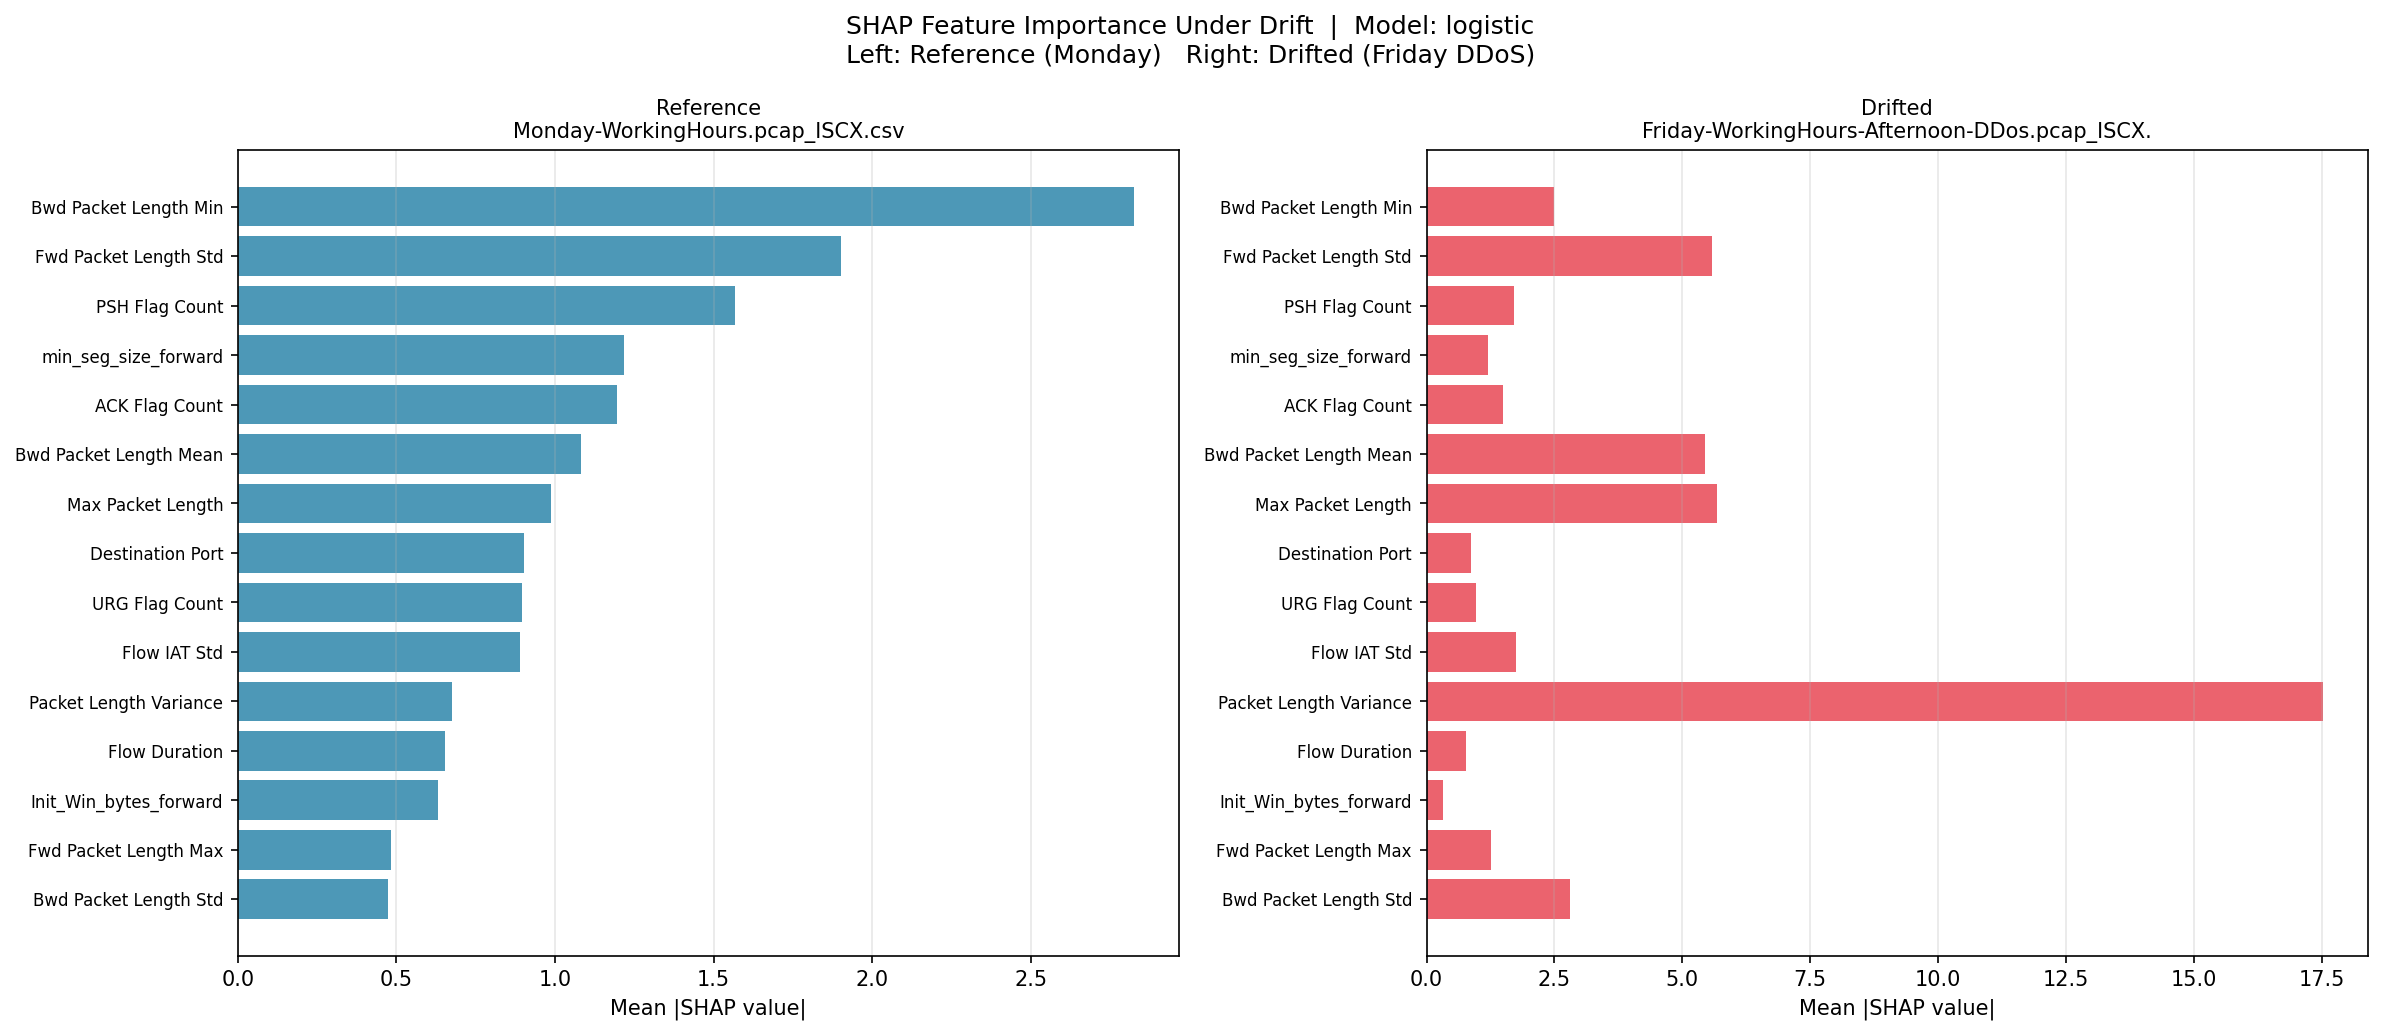

  Top 5 features (by reference importance):
    Bwd Packet Length Min                  ref=2.8267  drift=2.4952  delta=-0.3314
    Fwd Packet Length Std                  ref=1.9002  drift=5.5785  delta=+3.6783
    PSH Flag Count                         ref=1.5675  drift=1.7036  delta=+0.1361
    min_seg_size_forward                   ref=1.2170  drift=1.2017  delta=-0.0153
    ACK Flag Count                         ref=1.1958  drift=1.4976  delta=+0.3019

--- SHAP: svm ---


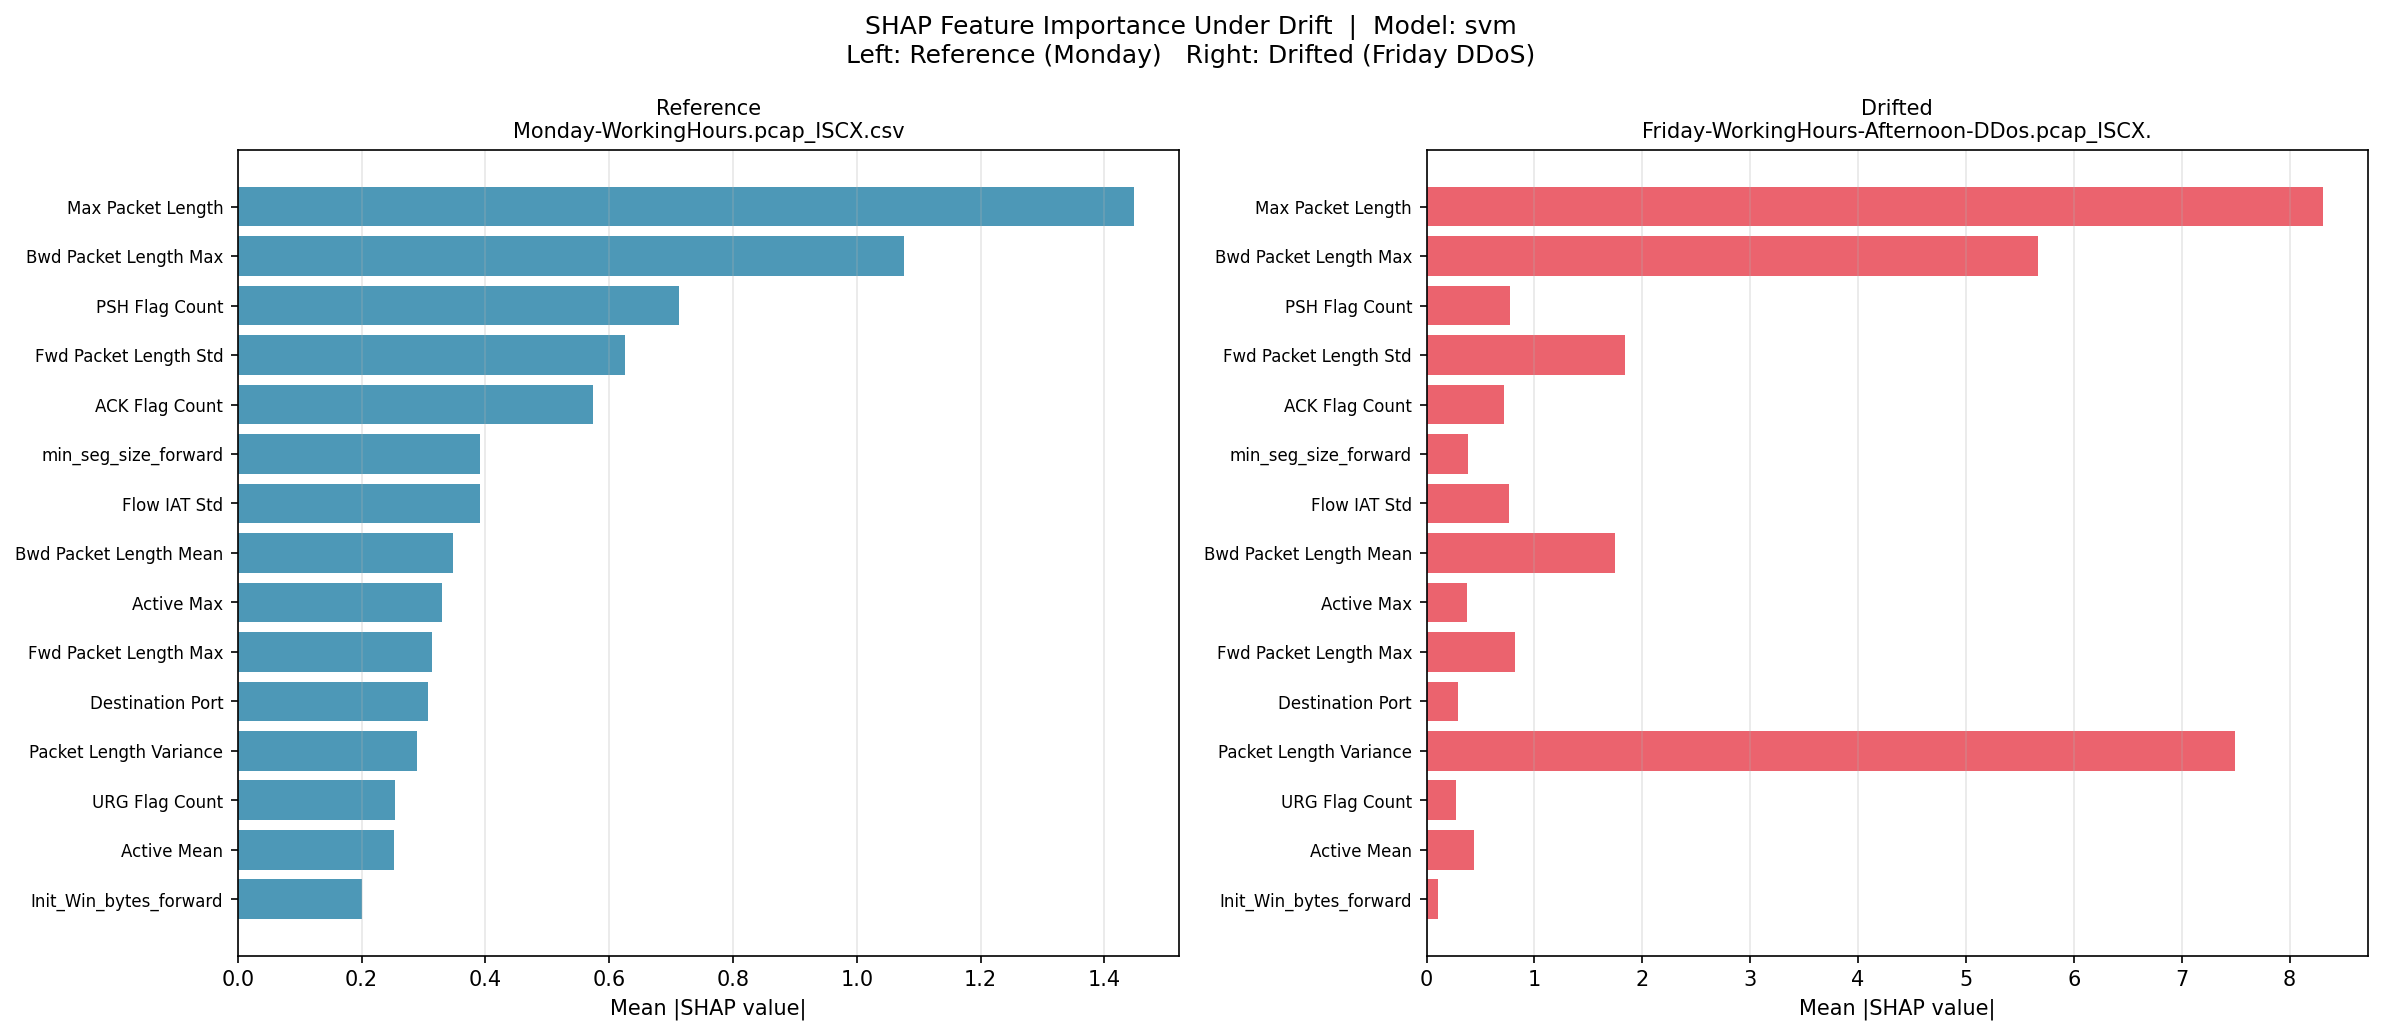

  Top 5 features (by reference importance):
    Max Packet Length                      ref=1.4487  drift=8.3124  delta=+6.8637
    Bwd Packet Length Max                  ref=1.0757  drift=5.6681  delta=+4.5924
    PSH Flag Count                         ref=0.7133  drift=0.7752  delta=+0.0619
    Fwd Packet Length Std                  ref=0.6250  drift=1.8348  delta=+1.2098
    ACK Flag Count                         ref=0.5740  drift=0.7189  delta=+0.1449


In [18]:
# Cell 10 — Display SHAP comparison plots (generated by shap_analysis.py)

from IPython.display import Image, display

shap_models = ["random_forest", "xgboost", "decision_tree", "logistic", "svm"]
found = False

for model_name in shap_models:
    shap_path = f"{REPORTS}/shap_comparison_{model_name}.png"
    if os.path.exists(shap_path):
        print(f"\n--- SHAP: {model_name} ---")
        display(Image(shap_path))
        found = True

        # Print numeric shift from JSON
        json_path = f"{REPORTS}/shap_values_{model_name}.json"
        if os.path.exists(json_path):
            with open(json_path) as f:
                sv = json.load(f)
            print(f"  Top 5 features (by reference importance):")
            for feat in sv["top_features"][:5]:
                rv = sv["reference_mean_abs_shap"].get(feat, 0)
                dv = sv["drifted_mean_abs_shap"].get(feat, 0)
                print(f"    {feat:<38} ref={rv:.4f}  drift={dv:.4f}  delta={dv-rv:+.4f}")

if not found:
    print("No SHAP plots found. Run this first:")
    print("  pip install shap")
    print("  python src/shap_analysis.py")

## Drift Alerts
Batches where the average cross-model accuracy fell below the configured threshold.

In [20]:
# Cell 11 — Drift alerts summary

if alerts:
    print(f"{'='*70}")
    print(f"DRIFT ALERTS — {len(alerts)} batch(es) below threshold")
    print(f"{'='*70}")
    for a in alerts:
        label = SHORT.get(a["batch"], a["batch"][:30])
        print(f"\nBatch         : {label}")
        print(f"Avg accuracy  : {a['average_accuracy']*100:.2f}%  (threshold: {a['threshold']*100:.0f}%)")
        print(f"KL divergence : {a.get('label_kl_divergence', 'N/A')}")
        if a.get("predicted_accuracy"):
            print(f"Predicted acc : {a['predicted_accuracy']*100:.2f}%")
        print(f"Per-model     :")
        for m, acc in a.get("per_model_accuracy", {}).items():
            print(f"  {m:<20}: {acc*100:.2f}%")
else:
    print("No drift alerts — all batches above threshold.")
    print("(Adjust DRIFT_ALERT_THRESHOLD in config.py to tune sensitivity.)")

DRIFT ALERTS — 3 batch(es) below threshold

Batch         : Wed
Avg accuracy  : 63.48%  (threshold: 80%)
KL divergence : 7.752125
Per-model     :
  random_forest       : 63.48%
  xgboost             : 63.48%
  logistic            : 63.48%
  decision_tree       : 63.48%
  svm                 : 63.48%

Batch         : Fri Port
Avg accuracy  : 44.52%  (threshold: 80%)
KL divergence : 12.08758
Per-model     :
  random_forest       : 44.52%
  xgboost             : 44.52%
  logistic            : 44.52%
  decision_tree       : 44.52%
  svm                 : 44.52%

Batch         : Fri DDoS
Avg accuracy  : 43.33%  (threshold: 80%)
KL divergence : 12.365228
Per-model     :
  random_forest       : 43.33%
  xgboost             : 43.33%
  logistic            : 43.33%
  decision_tree       : 43.33%
  svm                 : 43.33%


## Summary Table
Complete results with all metrics and all models.

In [22]:
# Cell 12 — Full summary table

print("\n=== DRIFT SCORES SUMMARY (fixed reference) ===")
print(f"{'Batch':<12} {'KL':>8} {'JS':>8} {'Wasserstein':>13} {'Mean FeatJS':>13}")
print("-" * 60)
for _, row in df_drift.iterrows():
    ws = row.get("label_wasserstein", "N/A")
    ws_str = f"{ws:.4f}" if isinstance(ws, float) else str(ws)
    print(f"{row['label']:<12} {row['label_kl_divergence']:>8.4f} "          f"{row['label_js_divergence']:>8.4f} {ws_str:>13} "          f"{row['mean_feature_js']:>13.6f}")

if "model" in df_eval.columns:
    print("\n=== CROSS-EVAL ACCURACY BY MODEL ===")
    pivot_print = df_eval.pivot_table(index="label", columns="model",
                                      values="accuracy", aggfunc="first")
    print(pivot_print.to_string(float_format="{:.4f}".format))
else:
    print("\n=== CROSS-EVAL ACCURACY (single model) ===")
    for _, row in df_eval.iterrows():
        print(f"  {row['label']:<12} {row['accuracy']*100:.2f}%")


=== DRIFT SCORES SUMMARY (fixed reference) ===
Batch              KL       JS   Wasserstein   Mean FeatJS
------------------------------------------------------------
Tue            0.5770   0.0109        0.0311      0.000590
Wed            7.7521   0.1471        0.3652      0.023529
Thu AM         0.2071   0.0041        0.0118      0.001294
Thu PM         0.0018   0.0000        0.0001      0.002677
Fri AM         0.1821   0.0036        0.0104      0.001343
Fri Port      12.0876   0.2469        0.4452      0.010968
Fri DDoS      12.3652   0.2540        0.4333      0.034122

=== CROSS-EVAL ACCURACY BY MODEL ===
model     decision_tree  logistic  random_forest    svm  xgboost
label                                                           
Fri AM           0.9896    0.9896         0.9896 0.9896   0.9896
Fri DDoS         0.4333    0.4333         0.4333 0.4333   0.4333
Fri Port         0.4452    0.4452         0.4452 0.4452   0.4452
Mon              1.0000    1.0000         1.0000 1.0000 